# ДЗ 2

Ткачук, «Математика — абитуриенту». 30 вопросов по тексту и 10 без ответа. Формулы не проверяются. Код — в `homework02.py`, результаты — в `results/`. По умолчанию новых вызовов API нет.

In [1]:
import json
import pandas as pd
from IPython.display import display, Image
import homework02 as hw
import run_experiments as experiment

RECOMPUTE = False
pages, tasks, negatives = experiment.datasets()
print(f"Страниц: {len(pages)}, вопросов: {len(tasks)}, без ответа: {len(negatives)}")

Страниц: 931, вопросов: 30, без ответа: 10


## Нарезка

Целые страницы и блоки по 400 символов. Обе нарезки могут обрывать контекст.

In [2]:
chars = [c for p in pages for c in hw.chunk_chars(p)]
assert min(len(pages), len(chars)) >= 300
assert all(any(p['pdf_page'] == t['pdf_page'] and t['evidence'] in p['text'] for p in pages) for t in tasks)
print('Фрагментов:', len(pages), 'и', len(chars))

Фрагментов: 931 и 4656


## Поиск

Эмбеддинги: text-embedding-3-small, 512, с кэшем. Recall ниже считается в NumPy. Верный кусок проверяется по документу, странице, ответу и половине слов цитаты. Отрицательные вопросы исключены.

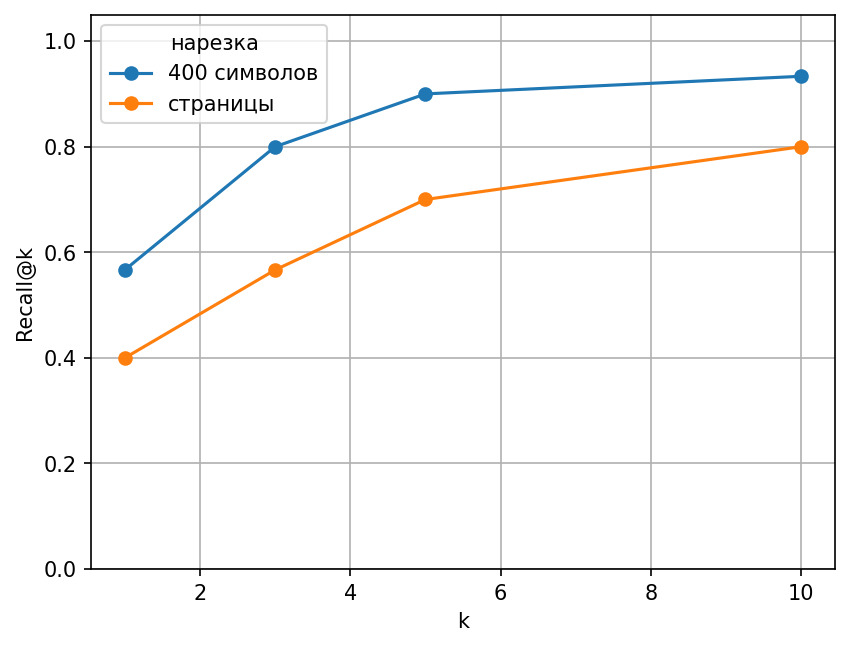

,поиск,recall@1,recall@5,recall@10
0,вектор,0.567,0.900,0.933
1,слова,0.533,0.733,0.767
2,гибрид RRF,0.600,0.900,0.900


Выбрано: 400 символов k = 5


In [3]:
if RECOMPUTE:
    experiment.retrieval()
display(Image(filename=str(hw.OUT / 'recall.png')))
display(pd.DataFrame(hw.RESULTS['hybrid'])[['поиск', 'recall@1', 'recall@5', 'recall@10']].round(3))
hw.K = hw.RESULTS['retrieval']['k']
print('Выбрано:', hw.RESULTS['retrieval']['chosen'], 'k =', hw.K)

Выбраны 400 символов и k=5: 27/30 в NumPy, при k=10 — 28/30. Гибрид при k=5 не помог. В Milvus результат хуже — 24/30.

In [4]:
milvus = hw.RESULTS['milvus']
print('Фильтр:', milvus['filter'])
display(pd.DataFrame(milvus['hits'])[['pdf_page', 'text']].head(1))
print('Recall@5 в Milvus:', milvus['actual_recall']['5'])

Фильтр: pdf_page <= 30


,pdf_page,text
0,3,"мся старших классов, учителям математики, руко..."


Recall@5 в Milvus: 0.8


## RAG и инструмент

RAG ищет всегда, агент вызывает knowledge_base сам. Схема описана в коде. Ниже тесты без API.

In [5]:
import unittest
import test_homework02
suite = unittest.defaultTestLoader.loadTestsFromModule(test_homework02)
assert unittest.TextTestRunner(verbosity=1).run(suite).wasSuccessful()

.

.

.

.

.

.

----------------------------------------------------------------------
Ran 6 tests in 0.002s

OK


## Ответы

Пять вариантов, по 40 вопросов. Основная таблица — по 30 вопросам с ответом. Старый кэш не включён в стоимость. Проверка синонимов сохранена в results.json вместе с исходными ответами.

,config,n,accuracy,cost_per_question,cost_per_correct
0,strong_plain,30,0.400000,0.002108,0.005269
1,cheap_plain,30,0.166667,0.000026,0.000156
2,cheap_rag,30,0.733333,0.000161,0.000220
3,cheap_agent,30,0.833333,0.000382,0.000458
4,mid_rag,30,0.800000,0.002085,0.002607


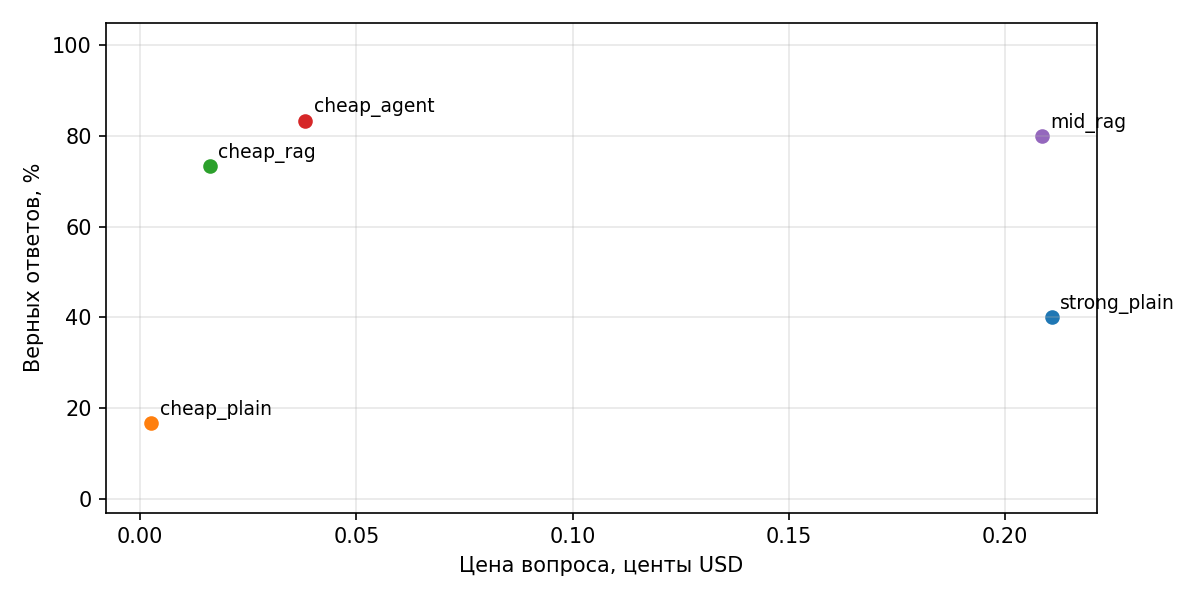

,config,true_refusals,false_refusals
0,strong_plain,10,13
1,cheap_plain,10,16
2,cheap_rag,10,2
3,cheap_agent,10,1
4,mid_rag,10,4


In [6]:
if RECOMPUTE:
    experiment.answers()
display(pd.DataFrame(hw.RESULTS['report']).round(6))
display(Image(filename=str(hw.OUT / 'money.png')))
display(pd.DataFrame(hw.RESULTS['refusals']))

## Ошибки

Два примера. У лучшего агента все ошибки связаны с поиском, поэтому пример ошибки генерации взят из обычного RAG.

In [7]:
for config, question_id in [('cheap_agent', 'tkachuk-023'), ('cheap_rag', 'tkachuk-003')]:
    row = next(r for r in hw.RESULTS[config] if r['id'] == question_id)
    print(config, question_id, row['question'])
    print('Эталон:', row['gold'])
    print('Ответ:', hw.final_answer(row['answer']), '\n')

cheap_agent tkachuk-023 Как называется глава Справочника, предназначенная для быстрого напоминания забытых формул и вводных сведений?
Эталон: Шпаргалки
Ответ: Справочные материалы (стр. 4). 

cheap_rag tkachuk-003 На каких экзаменах традиционно давались задания, включённые в книгу, согласно рекомендациям Семенова?
Эталон: вступительных
Ответ: Задания традиционно давались на вступительных экзаменах в вузы и ЕГЭ. 



## Память

Проверка на вымышленной Лене. Вторая сессия не получает историю первой. После переезда Пермь заменяет Казань в базе.

In [8]:
if RECOMPUTE:
    experiment.memory()
memory = hw.RESULTS['memory']
for turn in memory['demo']:
    print(f"Сессия {turn['session']}: {turn['question']}")
    print(turn['answer'], '\n')
print('До:', memory['facts1'])
print('После:', memory['facts2'])

Сессия 1: Меня зовут Лена, я живу в Казани. Готовлюсь к вступительным экзаменам. Предпочитаю короткие ответы.
Привет, Лена! Как я могу помочь тебе с подготовкой к экзаменам? 

Сессия 1: Сколько вариантов в день рекомендует решать Ткачук?
Ткачук рекомендует решать не более одного варианта в день, отводя на него 4 часа, как на экзамене. (файл: 1611656236_matematika-abiturientu_tkachuk-v_v_2018-18-e-izd-944s.pdf, страница PDF 29) 

FINAL: 1 вариант в день. 

Сессия 2: Как меня зовут, где я живу и к чему готовлюсь?
Тебя зовут Лена, ты готовишься к вступительным экзаменам. Информация о месте проживания отсутствует. FINAL: Лена, готовишься к вступительным экзаменам. 

Сессия 2: Я переехала: теперь живу в Перми, а не в Казани.
Спасибо за обновление! Теперь ты живешь в Перми. FINAL: Ты живешь в Перми. 

До: {'name': 'Лена', 'city': 'Казань', 'goal': 'Готовлюсь к вступительным экзаменам', 'preferences': 'Предпочитаю короткие ответы', 'interests': ''}
После: {'name': 'Лена', 'city': 'Пермь', 'go

## Токены

10 одинаковых реплик: вся история или четыре последних сообщения с фактами. Учтены все шаги агента. Ответы и вызовы инструментов могут различаться.

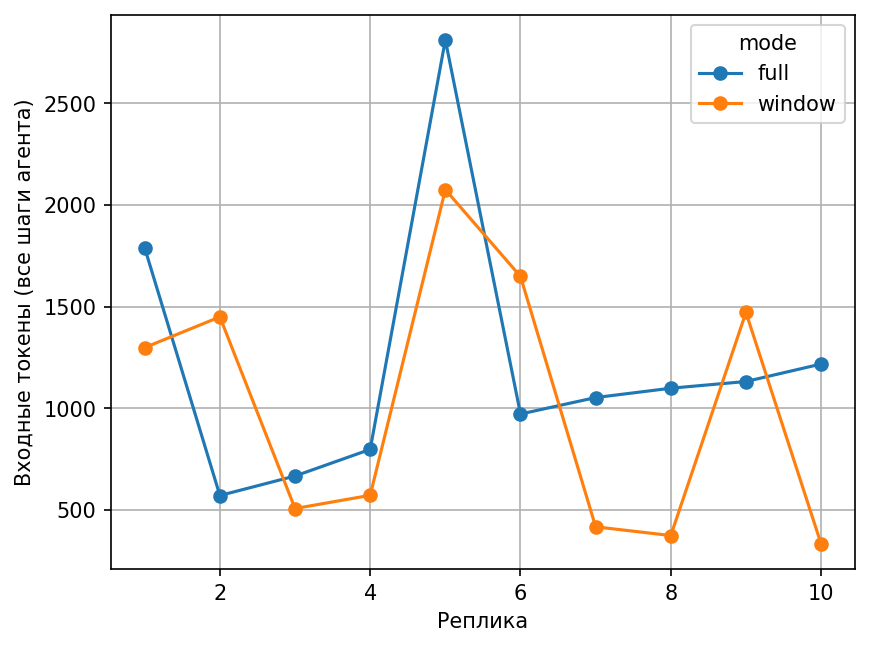

,mode,prompt,cost
0,full,12112,0.001960
1,window,10149,0.002002


In [9]:
display(Image(filename=str(hw.OUT / 'memory_tokens.png')))
display(pd.DataFrame(hw.RESULTS['memory_summary']))

## Вывод

Итоги — в README. Проверена работа по тексту, а не решение задач.